<a href="https://colab.research.google.com/github/parsasafaie/ImagePRO/blob/main/trained_models/Fashion_MNIST_cnn_image_classifier/Fashion_MNIST_cnn_image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p data
!wget -O data/t10k-images-idx3-ubyte.gz https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/Fashion_MNIST_cnn_image_classifier/data/t10k-images-idx3-ubyte.gz
!wget -O data/t10k-labels-idx1-ubyte.gz https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/Fashion_MNIST_cnn_image_classifier/data/t10k-labels-idx1-ubyte.gz
!wget -O data/train-images-idx3-ubyte.gz https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/Fashion_MNIST_cnn_image_classifier/data/train-images-idx3-ubyte.gz
!wget -O data/train-labels-idx1-ubyte.gz https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/Fashion_MNIST_cnn_image_classifier/data/train-labels-idx1-ubyte.gz

--2025-07-16 09:27:51--  https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/Fashion_MNIST_cnn_image_classifier/data/t10k-images-idx3-ubyte.gz
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/parsasafaie/ImagePRO/refs/heads/main/trained_models/Fashion_MNIST_cnn_image_classifier/data/t10k-images-idx3-ubyte.gz [following]
--2025-07-16 09:27:51--  https://raw.githubusercontent.com/parsasafaie/ImagePRO/refs/heads/main/trained_models/Fashion_MNIST_cnn_image_classifier/data/t10k-images-idx3-ubyte.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4422102 (4.2M) [application/octet

In [2]:
!pip install tensorflow
!pip install numpy
!pip install matplotlib
!pip install idx2numpy

In [3]:
import numpy as np
import idx2numpy
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
import os
for filename in os.listdir():
    if filename.endswith('.gz'):
        print(f"Found file: {filename}")

In [5]:
%%bash
cd data
gunzip -k *.gz

In [6]:
x_train = idx2numpy.convert_from_file('data/train-images-idx3-ubyte')
y_train = idx2numpy.convert_from_file('data/train-labels-idx1-ubyte')
x_test = idx2numpy.convert_from_file('data/t10k-images-idx3-ubyte')
y_test = idx2numpy.convert_from_file('data/t10k-labels-idx1-ubyte')

x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

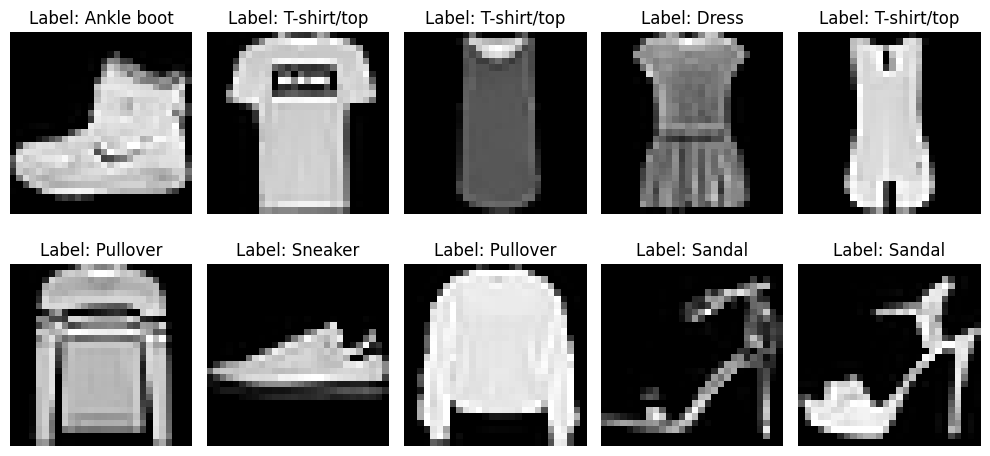

In [8]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {class_names[y_train[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.7623 - loss: 0.6594 - val_accuracy: 0.8703 - val_loss: 0.3636
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.8792 - loss: 0.3311 - val_accuracy: 0.8757 - val_loss: 0.3494
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.8976 - loss: 0.2783 - val_accuracy: 0.8897 - val_loss: 0.3005
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9122 - loss: 0.2397 - val_accuracy: 0.8998 - val_loss: 0.2765
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9189 - loss: 0.2137 - val_accuracy: 0.9048 - val_loss: 0.2732
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9280 - loss: 0.1892 - val_accuracy: 0.9106 - val_loss: 0.2538
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9342 - loss: 0.1743 - val_accuracy: 0.9094 - val_loss: 0.2565
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9420 -

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 - 3s - 8ms/step - accuracy: 0.9137 - loss: 0.2692

Test accuracy: 0.9137


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step


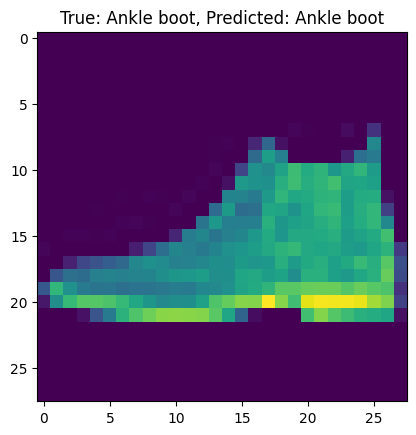

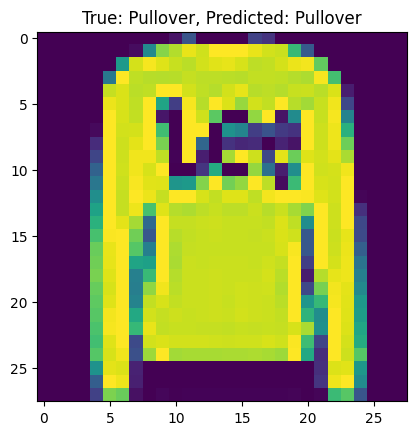

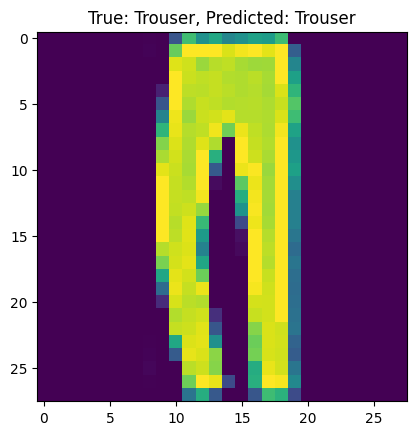

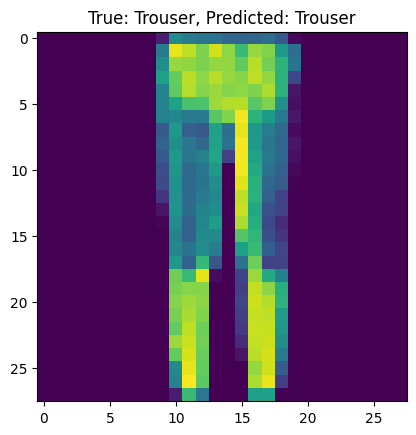

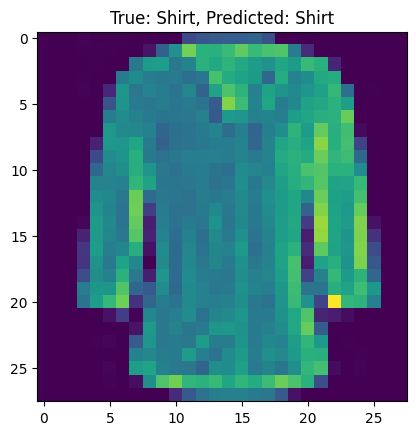

In [13]:
predicted_probs = model.predict(x_test[:5])
predicted_labels = tf.argmax(predicted_probs, axis=1)
for i in range(5):
    plt.imshow(x_test[i])
    plt.title(f"True: {class_names[y_test[i]]}, Predicted: {class_names[predicted_labels[i]]}")
    plt.show()

In [14]:
model.save('Fashion_MNIST_cnn_image_classifier.keras')